In [14]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [16]:
DATASET_PATH = "/content/drive/MyDrive/plant-disease-ai/dataset"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 16

SEED = 42

In [17]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6652 files belonging to 6 classes.
Using 5322 files for training.


In [18]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6652 files belonging to 6 classes.
Using 1330 files for validation.


In [19]:
class_names = train_dataset.class_names

print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']


In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [21]:
data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2)

])

In [22]:
custom_cnn = Sequential([

    # Augmentation
    data_augmentation,

    # Normalize
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    # Output
    layers.Dense(6, activation='softmax')

])

In [23]:
custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [26]:
history_cnn = custom_cnn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8713 - loss: 0.3599 - val_accuracy: 0.6594 - val_loss: 1.2445
Epoch 2/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8737 - loss: 0.3465 - val_accuracy: 0.9353 - val_loss: 0.1960
Epoch 3/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8869 - loss: 0.3103 - val_accuracy: 0.9128 - val_loss: 0.2550
Epoch 4/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8982 - loss: 0.2921 - val_accuracy: 0.9241 - val_loss: 0.2125
Epoch 5/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8955 - loss: 0.3030 - val_accuracy: 0.9278 - val_loss: 0.2042


In [27]:
cnn_loss, cnn_acc = custom_cnn.evaluate(validation_dataset)

print("Custom CNN Accuracy :", cnn_acc)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9353 - loss: 0.1960
Custom CNN Accuracy : 0.9353383183479309


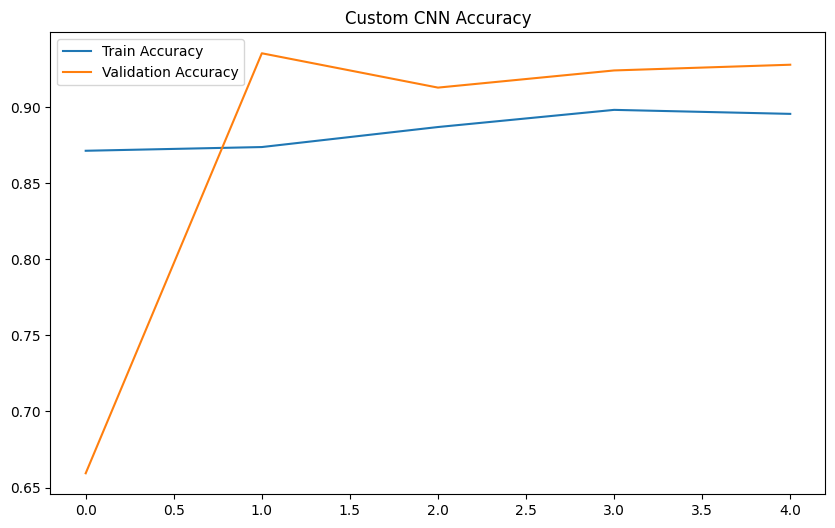

In [33]:
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']

plt.figure(figsize=(10,6))

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Custom CNN Accuracy")

plt.savefig(
    "/content/drive/MyDrive/plant-disease-ai/models/custom_cnn_accuracy.png",
    bbox_inches='tight'
)

plt.show()

In [34]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [35]:
# Base model
base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)


In [36]:
# Freeze pretrained layers
base_model.trainable = False

In [37]:
# Build model
efficientnet_model = Sequential([

    # Augmentation
    data_augmentation,

    # EfficientNet preprocessing
    layers.Lambda(preprocess_input),

    # Base model
    base_model,

    # Pooling
    layers.GlobalAveragePooling2D(),

    # Dense
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(6, activation='softmax')

])

In [38]:
efficientnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
history_eff = efficientnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 34s 64ms/step - accuracy: 0.8660 - loss: 0.3792 - val_accuracy: 0.8617 - val_loss: 0.3824
Epoch 2/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9258 - loss: 0.2087 - val_accuracy: 0.9353 - val_loss: 0.1844
Epoch 3/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9382 - loss: 0.1661 - val_accuracy: 0.9173 - val_loss: 0.2139
Epoch 4/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9414 - loss: 0.1509 - val_accuracy: 0.9474 - val_loss: 0.1312
Epoch 5/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.9436 - loss: 0.1505 - val_accuracy: 0.9421 - val_loss: 0.1748
Epoch 6/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9523 - loss: 0.1329 - val_accuracy: 0.9632 - val_loss: 0.1121
Epoch 7/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9558 - loss: 0.1233 - val_accuracy: 0.9647 - val_loss: 0.1046
Epoch 8/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.9526 - loss: 0.1201 - 

In [40]:
eff_loss, eff_acc = efficientnet_model.evaluate(validation_dataset)

print("EfficientNetB0 Accuracy :", eff_acc)

84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9647 - loss: 0.1046
EfficientNetB0 Accuracy : 0.9646616578102112


## Générer les prédictions

In [41]:
# =====================================
# GENERATE PREDICTIONS
# =====================================

import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = efficientnet_model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92m

## Créer la Confusion Matrix

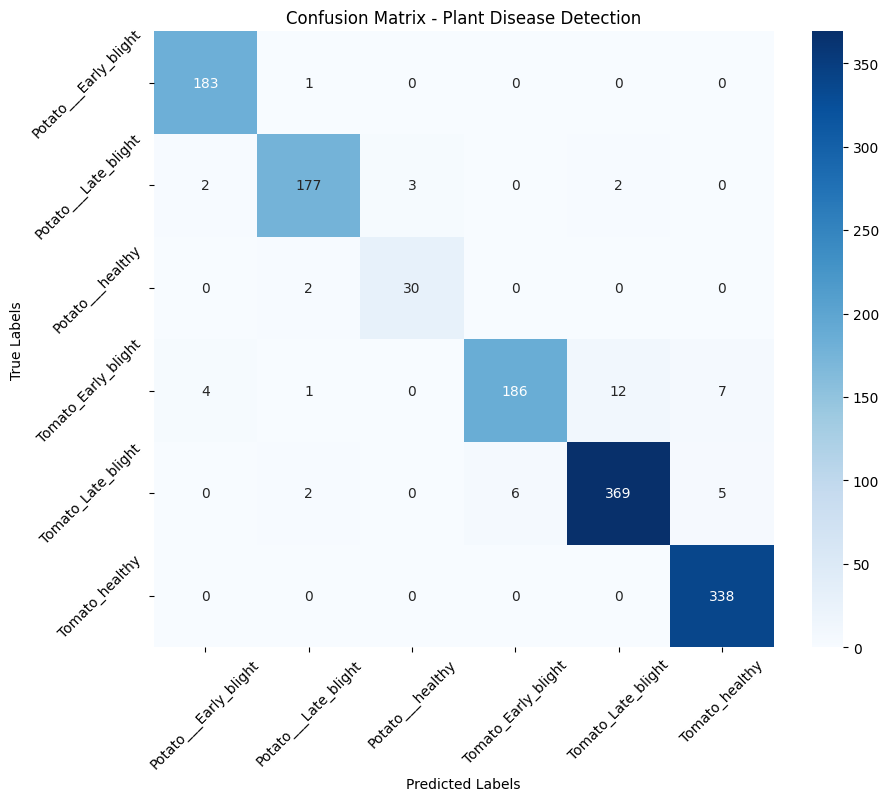

In [42]:
# =====================================
# CONFUSION MATRIX
# =====================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("Confusion Matrix - Plant Disease Detection")

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.savefig(
    "/content/drive/MyDrive/plant-disease-ai/models/confusion_matrix_EfficientNet.png",
    bbox_inches='tight'
)

plt.show()

## Classification Report

In [43]:
# =====================================
# CLASSIFICATION REPORT
# =====================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                       precision    recall  f1-score   support

Potato___Early_blight       0.97      0.99      0.98       184
 Potato___Late_blight       0.97      0.96      0.96       184
     Potato___healthy       0.91      0.94      0.92        32
  Tomato_Early_blight       0.97      0.89      0.93       210
   Tomato_Late_blight       0.96      0.97      0.96       382
       Tomato_healthy       0.97      1.00      0.98       338

             accuracy                           0.96      1330
            macro avg       0.96      0.96      0.96      1330
         weighted avg       0.96      0.96      0.96      1330



## Fine-Tuning


In [44]:
base_model.trainable = True

In [45]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
history_finetune = efficientnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 115s 218ms/step - accuracy: 0.7835 - loss: 0.5936 - val_accuracy: 0.8925 - val_loss: 0.2883
Epoch 2/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 67s 200ms/step - accuracy: 0.8799 - loss: 0.3430 - val_accuracy: 0.9188 - val_loss: 0.2304
Epoch 3/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 67s 201ms/step - accuracy: 0.9104 - loss: 0.2544 - val_accuracy: 0.9338 - val_loss: 0.1849
Epoch 4/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 67s 200ms/step - accuracy: 0.9235 - loss: 0.2128 - val_accuracy: 0.9519 - val_loss: 0.1399
Epoch 5/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 67s 202ms/step - accuracy: 0.9357 - loss: 0.1775 - val_accuracy: 0.9586 - val_loss: 0.1192


In [47]:
custom_cnn.save(
    "/content/drive/MyDrive/plant-disease-ai/models/custom_cnn_model.h5"
)

In [48]:
efficientnet_model.save(
    "/content/drive/MyDrive/plant-disease-ai/models/efficientnet_model.h5"
)

In [49]:
import os

models_path = "/content/drive/MyDrive/plant-disease-ai/models/"
for f in os.listdir(models_path):
    if "efficientnet" in f or "custom_cnn" in f or "confusion" in f:
        print(f"✅ {f} - {os.path.getsize(os.path.join(models_path, f)) / (1024**2):.1f} MB")

✅ confusion_matrix.png - 0.1 MB
✅ custom_cnn_accuracy.png - 0.0 MB
✅ confusion_matrix_EfficientNet.png - 0.1 MB
✅ custom_cnn_model.h5 - 254.6 MB
✅ efficientnet_model.h5 - 48.6 MB


In [50]:
print(f"Custom CNN accuracy : {cnn_acc:.4f}")
print(f"EfficientNet accuracy : {eff_acc:.4f}")

Custom CNN accuracy : 0.9353
EfficientNet accuracy : 0.9647


In [51]:
import pickle
with open("/content/drive/MyDrive/plant-disease-ai/models/history_eff.pkl", "wb") as f:
    pickle.dump(history_eff.history, f)
with open("/content/drive/MyDrive/plant-disease-ai/models/history_finetune.pkl", "wb") as f:
    pickle.dump(history_finetune.history, f)

In [53]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

model = load_model(
    "/content/drive/MyDrive/plant-disease-ai/models/efficientnet_model.h5",
    custom_objects={'preprocess_input': preprocess_input}
)